# Classification Task: Non-Order Preserving Sequences of Partitions

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

from tqdm import tqdm

# disable sklear warnings
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [2]:
# We set a global configuration for matplotlib to obtain well-readable plots
SMALL_SIZE = 15
MEDIUM_SIZE = 15
BIGGER_SIZE = 15

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=BIGGER_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

## Load Data

We first process the raw synthetic data computed by `ranking_task_data.py`.

In [ ]:
# N_SAMPLES = 5000 + 1870
# SEED = 42

# hf0_a = []
# hf1_a = []
# nce_a = []
# partitions_a = []

# hf0_b = []
# hf1_b = []
# nce_b = []
# n_swaps_b = []
# partitions_b = []

# for i in range(2000,N_SAMPLES):
#     try:
#         mcbif = load_results(f"data//group_a/mcbif_a_{i}.pkl")
#         hf0_a.append(mcbif["betti_0_rank"])
#         hf1_a.append(mcbif["betti_1_rank"])
#         nce = np.load(f"data/group_a/nce_a_{i}.npy")
#         nce_a.append(nce)
#         partitions_a.append(np.load(f"data/group_a/partitions_a_{i}.npy"))

#         mcbif = load_results(f"data/group_b/mcbif_b_{i}.pkl")
#         hf0_b.append(mcbif["betti_0_rank"])
#         hf1_b.append(mcbif["betti_1_rank"])
#         nce = np.load(f"data/group_b/nce_b_{i}.npy")
#         nce_b.append(nce)
#         n_swaps = np.load(f"data/group_b/n_swaps_b_{i}.npy")
#         n_swaps_b.append(n_swaps)
#         partitions_b.append(np.load(f"data/group_b/partitions_b_{i}.npy"))
#     except FileNotFoundError:
#         continue

# hf0_a = np.array(hf0_a)
# hf1_a = np.array(hf1_a)
# nce_a = np.array(nce_a)
# hf0_b = np.array(hf0_b)
# hf1_b = np.array(hf1_b)
# nce_b = np.array(nce_b)

# partitions_a = np.array(partitions_a)
# partitions_b = np.array(partitions_b)
# n_swaps_b = np.array(n_swaps_b)

# # save arrays for later use
# np.save("results/hf0_a.npy", hf0_a)
# np.save("results/hf1_a.npy", hf1_a)
# np.save("results/nce_a.npy", nce_a)
# np.save("results/hf0_b.npy", hf0_b)
# np.save("results/hf1_b.npy", hf1_b)
# np.save("results/nce_b.npy", nce_b)

# np.save("data/partitions_a.npy", partitions_a)
# np.save("data/partitions_b.npy", partitions_b)
# np.save("data/n_swaps_b.npy", n_swaps_b)

Due to the size of the raw data, we only provide the derivative measures here and load them.

In [5]:
# load arrays
hf0_a = np.load("results/hf0_a.npy")
hf1_a = np.load("results/hf1_a.npy")
nce_a = np.load("results/nce_a.npy")
hf0_b = np.load("results/hf0_b.npy")
hf1_b = np.load("results/hf1_b.npy")    
nce_b = np.load("results/nce_b.npy")
partitions_a = np.load("data/partitions_a.npy")
partitions_b = np.load("data/partitions_b.npy")
n_swaps_b = np.load("data/n_swaps_b.npy")

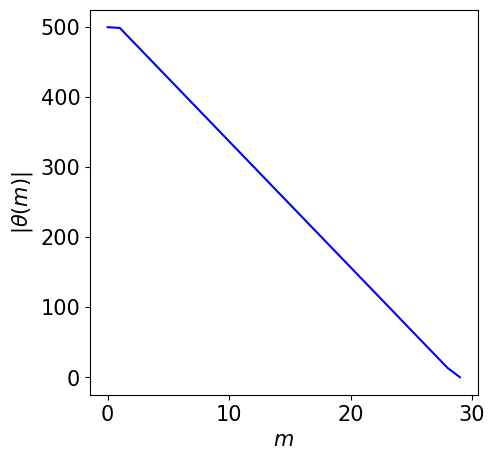

In [7]:
n_clusters = np.max(partitions_a, axis=2)
mean_n_clusters = np.mean(n_clusters, axis=0)

# Plot mean and standard deviation
fig, ax = plt.subplots(figsize=(5, 5))
x = np.arange(30)  # x-axis with 30 steps
ax.plot(x, mean_n_clusters, color='blue')
ax.set(xlabel=r'$m$', ylabel=r'$|\theta(m)|$')
plt.savefig("figures/ranking_task_n_clusters.png", bbox_inches="tight")


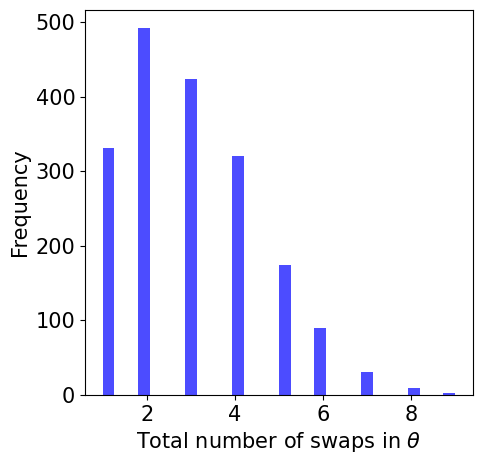

In [8]:
n_swaps_b_sum = np.sum(n_swaps_b, axis=1)
fig, ax = plt.subplots(figsize=(5, 5))
ax.hist(n_swaps_b_sum, bins=30, color='blue', alpha=0.7)
plt.xlabel(r'Total number of swaps in $\theta$')
plt.ylabel('Frequency')
# plt.title('Number of swaps ber $\theta$')
# plt.show()
plt.savefig("figures/ranking_task_n_swaps.png", bbox_inches="tight")


In [9]:
n_swaps_b_sum.mean()

np.float64(2.9775401069518717)

In [10]:
n_samples = hf0_a.shape[0]
M = hf0_a.shape[1]
normalisation = M * (M - 1) / 2

We also flatten the MCbiF feature maps.

In [42]:
hf0_a_flat = np.array([hf0[np.triu_indices(hf0.shape[1])] for hf0 in hf0_a])
hf1_a_flat = np.array([hf1[np.triu_indices(hf1.shape[1],k=1)] for hf1 in hf1_a])
hf0_b_flat = np.array([hf0[np.triu_indices(hf0.shape[1])] for hf0 in hf0_b])
hf1_b_flat = np.array([hf1[np.triu_indices(hf1.shape[1],k=1)] for hf1 in hf1_b])

## Compute ARI and MOD

We compute ARI and MOD as additional baseline feature maps.

### ARI

In [49]:
from sklearn.metrics.cluster import adjusted_rand_score

In [60]:
# compute pairwise ARI for each sequence of partitions
ari_a = []
for i in tqdm(range(n_samples)):
    ari_a_sample = np.zeros((M, M))
    for j in range(M):
        for k in range(j, M):
            ari_a_sample[j,k] = adjusted_rand_score(partitions_a[i][j], partitions_a[i][k])
            ari_a_sample[k,j] = ari_a_sample[j,k]
    ari_a.append(ari_a_sample)
ari_a = np.array(ari_a)

# save array
np.save("data/ranking_task/group_a/ari_a.npy", ari_a)

100%|██████████| 1870/1870 [02:52<00:00, 10.82it/s]


In [63]:
# compute pairwise ARI for each sequence of partitions
ari_b = []
for i in tqdm(range(n_samples)):
    ari_b_sample = np.zeros((M, M))
    for j in range(M):
        for k in range(j, M):
            ari_b_sample[j,k] = adjusted_rand_score(partitions_b[i][j], partitions_b[i][k])
            ari_b_sample[k,j] = ari_b_sample[j,k]
    ari_b.append(ari_b_sample)
ari_b = np.array(ari_b)

# save array
np.save("data/ranking_task/group_b/ari_b.npy", ari_b)

100%|██████████| 1870/1870 [02:51<00:00, 10.92it/s]


ARI_a: 2 min 52 s

ARI_b: 2 min 51 s

### MOD

MOD is available at: https://graph-tool.skewed.de/static/docs/stable/autosummary/graph_tool.inference.partition_overlap.html

In [8]:
import numpy as np
import graph_tool.all as gt

from tqdm import tqdm

In [12]:
n_samples = len(partitions_a)
M = partitions_a[0].shape[0]

In [ ]:
# compute pairwise MPO for each sequence of partitions
mod_a = []
for i in tqdm(range(n_samples)):
    mpo_a_sample = np.zeros((M, M))
    for j in range(M):
        for k in range(j, M):
            mpo_a_sample[j,k] = gt.partition_overlap(partitions_a[i][j], partitions_a[i][k])
            mpo_a_sample[k,j] = mpo_a_sample[j,k]
    mod_a.append(mpo_a_sample)
mod_a = np.array(mod_a)

# save array
np.save("results/mod_a.npy", mod_a)

100%|██████████| 1870/1870 [1:13:43<00:00,  2.37s/it]


In [ ]:
# compute pairwise MPO for each sequence of partitions
mod_b = []
for i in tqdm(range(n_samples)):
    mpo_b_sample = np.zeros((M, M))
    for j in range(M):
        for k in range(j, M):
            mpo_b_sample[j,k] = gt.partition_overlap(partitions_b[i][j], partitions_b[i][k])
            mpo_b_sample[k,j] = mpo_b_sample[j,k]
    mod_b.append(mpo_b_sample)
mod_b = np.array(mod_b)

# save array
np.save("results/mod_b.npy", mod_b)

100%|██████████| 1870/1870 [1:12:31<00:00,  2.33s/it]


MPO_a: 1h 13min 43s

MPO_b: 1h 12min 31s

Here we load the results directly.

In [33]:
# load ari and mpo data
ari_a = np.load(f"results/ari_a.npy")
ari_b = np.load(f"results/ari_b.npy")
mod_a = np.load(f"results/mod_a.npy")
mod_b = np.load(f"results/mod_b.npy")

## Statistical tests

In [34]:
vi_m_a = np.array([nce.sum()/normalisation for nce in nce_a])
vi_m_b = np.array([nce.sum()/normalisation for nce in nce_b])

ari_m_a = np.array([ari.sum()/normalisation for ari in ari_a])
ari_m_b = np.array([ari.sum()/normalisation for ari in ari_b])

mod_m_a = np.array([mpo.sum()/normalisation for mpo in mod_a])
mod_m_b = np.array([mpo.sum()/normalisation for mpo in mod_b])

In [35]:
c1_bar_a = np.array([hf1.sum()/normalisation for hf1 in hf1_a])
c1_bar_b = np.array([hf1.sum()/normalisation for hf1 in hf1_b])

In [36]:
def compute_c0_bar(hf0):
    M = hf0.shape[1]
    normalisation = M * (M - 1) / 2

    conflict_0 = np.zeros_like(hf0)

    for i in range(M):
        for j in range(i+1, M):
            conflict_0[i,j] = hf0[i,j] / np.min(np.diag(hf0)[i:j+1])

    return 1 - conflict_0.sum() / normalisation

In [37]:
c0_bar_a = [compute_c0_bar(hf0) for hf0 in hf0_a]
c0_bar_b = [compute_c0_bar(hf0) for hf0 in hf0_b]

We use the Mann-Whitney U test to analyse whether the measures can distinguish between the two classes.

/var/folders/3g/vtj6mz7j0k199ncr2gr0r6q00000gp/T/ipykernel_96052/4276116859.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data_hf0, x='Group', y='Value', ax=axes[0], palette=['blue', 'orange'])
/var/folders/3g/vtj6mz7j0k199ncr2gr0r6q00000gp/T/ipykernel_96052/4276116859.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data_hf1, x='Group', y='Value', ax=axes[1], palette=['blue', 'orange'])
/var/folders/3g/vtj6mz7j0k199ncr2gr0r6q00000gp/T/ipykernel_96052/4276116859.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Only cut vs. Swap and cut: Custom statistical test, P_val:1.245e-16
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Only cut vs. Swap and cut: Custom statistical test, P_val:0.000e+00
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Only cut vs. Swap and cut: Custom statistical test, P_val:4.250e-01
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Only cut vs. Swap and cut: C

/var/folders/3g/vtj6mz7j0k199ncr2gr0r6q00000gp/T/ipykernel_96052/4276116859.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data_ari, x='Group', y='Value', ax=axes[3], palette=['blue', 'orange'])
/var/folders/3g/vtj6mz7j0k199ncr2gr0r6q00000gp/T/ipykernel_96052/4276116859.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data_mpo, x='Group', y='Value', ax=axes[4], palette=['blue', 'orange'])


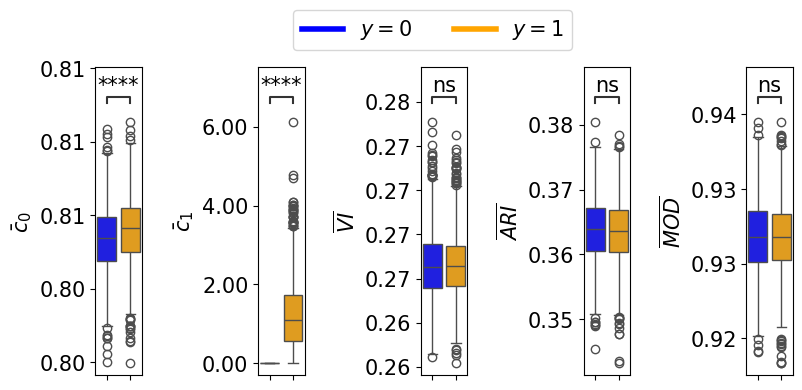

In [38]:
from statannotations.Annotator import Annotator
from scipy.stats import mannwhitneyu
import pandas as pd
import seaborn as sns

fig, axes = plt.subplots(1, 5, figsize=(9, 4))

plt.subplots_adjust(wspace=2.5, hspace=0.0)

# Define pairs for annotations
pairs = [('Only cut', 'Swap and cut')]

# Boxplot for hf0_m_a and hf0_m_b
data_hf0 = pd.DataFrame({'Group': ['Only cut'] * len(c0_bar_a) + ['Swap and cut'] * len(c0_bar_b),
                         'Value': np.concatenate([c0_bar_a, c0_bar_b])})
sns.boxplot(data=data_hf0, x='Group', y='Value', ax=axes[0], palette=['blue', 'orange'])
# axes[1].set_title('HF0')
U1, p_hf0 = mannwhitneyu(c0_bar_a, c0_bar_b)
annotator = Annotator(axes[0], pairs, data=data_hf0, x='Group', y='Value')
annotator.set_pvalues([p_hf0])
annotator.annotate()

# Boxplot for hf1_m_a and hf1_m_b
data_hf1 = pd.DataFrame({'Group': ['Only cut'] * len(c1_bar_a) + ['Swap and cut'] * len(c1_bar_b),
                         'Value': np.concatenate([c1_bar_a, c1_bar_b])})
sns.boxplot(data=data_hf1, x='Group', y='Value', ax=axes[1], palette=['blue', 'orange'])
# axes[2].set_title('HF1')
U1, p_hf1 = mannwhitneyu(c1_bar_a, c1_bar_b)
annotator = Annotator(axes[1], pairs, data=data_hf1, x='Group', y='Value')
annotator.set_pvalues([p_hf1])
annotator.annotate()

# Boxplot for vi_m_a and vi_m_b
data_nce = pd.DataFrame({'Group': ['Only cut'] * len(vi_m_a) + ['Swap and cut'] * len(vi_m_b),
                         'Value': np.concatenate([vi_m_a, vi_m_b])})
sns.boxplot(data=data_nce, x='Group', y='Value', ax=axes[2], palette=['blue', 'orange'])
# axes[0].set_title('NCE')
U1, p_nce = mannwhitneyu(vi_m_a, vi_m_b)
annotator = Annotator(axes[2], pairs, data=data_nce, x='Group', y='Value')
annotator.set_pvalues([p_nce])
annotator.annotate()

# Boxplot for ari_m_a and ari_m_b
data_ari = pd.DataFrame({'Group': ['Only cut'] * len(ari_m_a) + ['Swap and cut'] * len(ari_m_b),
                         'Value': np.concatenate([ari_m_a, ari_m_b])})
sns.boxplot(data=data_ari, x='Group', y='Value', ax=axes[3], palette=['blue', 'orange'])
U1, p_ari = mannwhitneyu(ari_m_a, ari_m_b)
annotator = Annotator(axes[3], pairs, data=data_ari, x='Group', y='Value')
annotator.set_pvalues([p_ari])
annotator.annotate()

# Boxplot for mpo_m_a and mpo_m_b
data_mpo = pd.DataFrame({'Group': ['Only cut'] * len(mod_m_a) + ['Swap and cut'] * len(mod_m_b),
                         'Value': np.concatenate([mod_m_a, mod_m_b])})
sns.boxplot(data=data_mpo, x='Group', y='Value', ax=axes[4], palette=['blue', 'orange'])
U1, p_mpo = mannwhitneyu(mod_m_a, mod_m_b)
annotator = Annotator(axes[4], pairs, data=data_mpo, x='Group', y='Value')
annotator.set_pvalues([p_mpo])
annotator.annotate()

plt.tight_layout()

# Update y-axis labels with descriptive names
axes[0].set_ylabel(r'$\bar c_0$')
axes[1].set_ylabel(r'$\bar c_1$')
axes[2].set_ylabel(r'$\overline{VI}$')
axes[3].set_ylabel(r'$\overline{ARI}$')
axes[4].set_ylabel(r'$\overline{MOD}$')


for ax in axes:
    try:
        ax.set_yticklabels([f'{float(label.get_text().replace("−", "-")):.2f}' for label in ax.get_yticklabels()])
        ax.set_xlabel('')  # Remove the label "Group" at the bottom of each plot
    except ValueError:
        pass

# Add a single legend for the groups
handles = [plt.Line2D([0], [0], color='blue', lw=4, label=r'$y=0$'),
            plt.Line2D([0], [0], color='orange', lw=4, label=r'$y=1$')]
fig.legend(handles=handles, loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.05))

# Remove x-axis labels from all subplots
for ax in axes:
    ax.set_xticklabels([])

plt.savefig("figures/ranking_task_boxplots.pdf", bbox_inches="tight")


## Logistic Regression

We next implement logistic regression and function to compute bootstrapped confidence intervals for the accuracy.

In [40]:
import numpy as np
from sklearn.metrics import accuracy_score

def compute_bootstrapped_accuracy_ci(y_true, y_pred, n_bootstraps=5000, conf_level=0.95):
    """
    Computes the confidence interval for the accuracy score using the 
    percentile bootstrap method on a test set.

    Args:
        y_true (array-like): Actual true values for the test set.
        y_pred (array-like): Predicted values for the test set.
        n_bootstraps (int): The number of bootstrap samples to draw. 
                            5000 is generally sufficient for precision.
        conf_level (float): The desired confidence level (e.g., 0.95 for 95% CI).

    Returns:
        tuple: (accuracy_observed, lower_bound, upper_bound)
               - accuracy_observed: The accuracy_score score computed on the original full test set.
               - lower_bound: The lower end of the confidence interval.
               - upper_bound: The upper end of the confidence interval.
    """
    
    # 1. Convert inputs to numpy arrays for efficient indexing
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    n_samples = len(y_true)

    if n_samples == 0:
        raise ValueError("Input arrays must not be empty.")
        
    # 2. Compute the primary point estimate on the full test set
    accuracy_observed = accuracy_score(y_true, y_pred)
    
    bootstrapped_scores = []
    
    # 3. Generate bootstrap samples and compute R2 for each
    for _ in range(n_bootstraps):
        # Draw indices with replacement
        indices = np.random.choice(n_samples, size=n_samples, replace=True)
        
        # Select data for this bootstrap sample
        true_sample = y_true[indices]
        pred_sample = y_pred[indices]
        
        # Calculate R2 for the sample
        score = accuracy_score(true_sample, pred_sample)
        bootstrapped_scores.append(score)
        
    # 4. Determine the confidence interval bounds using percentiles
    sorted_scores = np.array(sorted(bootstrapped_scores))
    
    # Calculate the indices for the desired percentiles (e.g., 2.5% and 97.5% for 95% CI)
    alpha = (1.0 - conf_level) / 2
    lower_percentile_index = int(alpha * n_bootstraps)
    upper_percentile_index = int((1 - alpha) * n_bootstraps)

    lower_bound = sorted_scores[lower_percentile_index]
    upper_bound = sorted_scores[upper_percentile_index]
    
    return accuracy_observed, lower_bound, upper_bound

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report


def run_logistic_regression(features_a: np.ndarray, features_b: np.array, flatten: bool = False):
    if flatten:
        # if asymmetric features, flatten to 1D
        if np.array_equal(features_a, features_a.transpose((0,2,1))) is False:
            features_a = features_a.reshape(features_a.shape[0], -1)
            features_b = features_b.reshape(features_b.shape[0], -1)
        else:
            features_a = np.array([f[np.triu_indices(f.shape[1])] for f in features_a])
            features_b = np.array([f[np.triu_indices(f.shape[1])] for f in features_b])

    # Combine features for a and b into a single dataset
    X = np.concatenate([features_a, features_b])
    y = np.concatenate([np.zeros(n_samples), np.ones(n_samples)])  # 0 for group_a, 1 for group_b

    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

    # Initialize and train the logistic regression model
    model = LogisticRegression(max_iter=1000, random_state=SEED)
    model.fit(X_train, y_train)

    # Predict on the test set
    y_pred = model.predict(X_test)

    # Print classification report
    print(classification_report(y_test, y_pred))

    # Compute 95% confidence interval for accuracy
    accuracy, lower_ci, upper_ci = compute_bootstrapped_accuracy_ci(y_test, y_pred)
    print(f"Accuracy 95% CI: {accuracy:.2f} ({lower_ci:.2f}--{upper_ci:.2f})")
    

### CE

In [43]:
run_logistic_regression(nce_a, nce_b, flatten=True)

              precision    recall  f1-score   support

         0.0       0.52      0.40      0.45       383
         1.0       0.49      0.61      0.54       365

    accuracy                           0.50       748
   macro avg       0.50      0.50      0.50       748
weighted avg       0.50      0.50      0.50       748

Accuracy 95% CI: 0.50 (0.47--0.54)


### HF0

In [44]:
run_logistic_regression(hf0_a_flat, hf0_b_flat)

              precision    recall  f1-score   support

         0.0       0.58      0.54      0.56       383
         1.0       0.55      0.59      0.57       365

    accuracy                           0.56       748
   macro avg       0.56      0.56      0.56       748
weighted avg       0.56      0.56      0.56       748

Accuracy 95% CI: 0.56 (0.53--0.60)


### HF1

In [45]:
run_logistic_regression(hf1_a_flat, hf1_b_flat)

              precision    recall  f1-score   support

         0.0       0.95      1.00      0.97       383
         1.0       1.00      0.94      0.97       365

    accuracy                           0.97       748
   macro avg       0.97      0.97      0.97       748
weighted avg       0.97      0.97      0.97       748

Accuracy 95% CI: 0.97 (0.96--0.98)


### HF0 + HF1

In [46]:
# Combine hf0 and hf1 features for both groups
hf_features_a = np.hstack([hf0_a_flat, hf1_a_flat])
hf_features_b = np.hstack([hf0_b_flat, hf1_b_flat])

run_logistic_regression(hf_features_a, hf_features_b)

              precision    recall  f1-score   support

         0.0       0.94      0.95      0.95       383
         1.0       0.95      0.94      0.94       365

    accuracy                           0.95       748
   macro avg       0.95      0.94      0.95       748
weighted avg       0.95      0.95      0.95       748

Accuracy 95% CI: 0.95 (0.93--0.96)


### Raw encoding

In [29]:
partitions_a_flat = partitions_a.reshape(partitions_a.shape[0], -1)
partitions_b_flat = partitions_b.reshape(partitions_b.shape[0], -1)

In [30]:
run_logistic_regression(partitions_a, partitions_b, flatten=True)

              precision    recall  f1-score   support

         0.0       0.53      0.75      0.62       383
         1.0       0.54      0.30      0.39       365

    accuracy                           0.53       748
   macro avg       0.53      0.53      0.50       748
weighted avg       0.53      0.53      0.51       748

Accuracy 95% CI: 0.53 (0.50--0.57)


### ARI

In [47]:
run_logistic_regression(ari_a, ari_b, flatten=True)

              precision    recall  f1-score   support

         0.0       0.50      0.45      0.47       383
         1.0       0.48      0.53      0.51       365

    accuracy                           0.49       748
   macro avg       0.49      0.49      0.49       748
weighted avg       0.49      0.49      0.49       748

Accuracy 95% CI: 0.49 (0.45--0.53)


### MOD

In [48]:
run_logistic_regression(mod_a, mod_b, flatten=True)

              precision    recall  f1-score   support

         0.0       0.47      0.41      0.44       383
         1.0       0.46      0.52      0.49       365

    accuracy                           0.46       748
   macro avg       0.46      0.47      0.46       748
weighted avg       0.47      0.46      0.46       748

Accuracy 95% CI: 0.46 (0.43--0.50)
